# Deconvolved Spatial Transcriptomics Data Analysis

### Import

In [1]:
# Import
library(Seurat)
library(BPCells)  
library(grid)
library(ggplot2)
library(viridis)
library(dplyr)
library(patchwork)
set.seed(1)

library(future)
plan("multicore", workers = 10)
options(future.globals.maxSize = 16000 * 1024^2)

future.seed=TRUE 

data_dir <- "./slice_Glioblastoma/deconvolved"

print("Loading 10X Spatial data...")
seurat_obj <- Load10X_Spatial(
  data.dir = data_dir,
)

seurat_obj@project.name <- "Glioblastoma"

bp_dir <- "codeconv_counts_bpcells"
if (!dir.exists(bp_dir)) {
  write_matrix_dir(mat = seurat_obj[["Spatial"]]$counts, dir = bp_dir)
}
seurat_obj[["Spatial"]]$counts <- open_matrix_dir(dir = bp_dir)

seurat_obj

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: viridisLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Loading 10X Spatial data..."


An object of class Seurat 
18031 features across 45530 samples within 1 assay 
Active assay: Spatial (18031 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: slice1

In [2]:
gc()

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,6113792,326.6,9415871,502.9,NA,9415871,502.9
Vcells,12625412,96.4,393409987,3001.5,16384,428246045,3267.3


### Preprocessing

[1] "Running QC..."


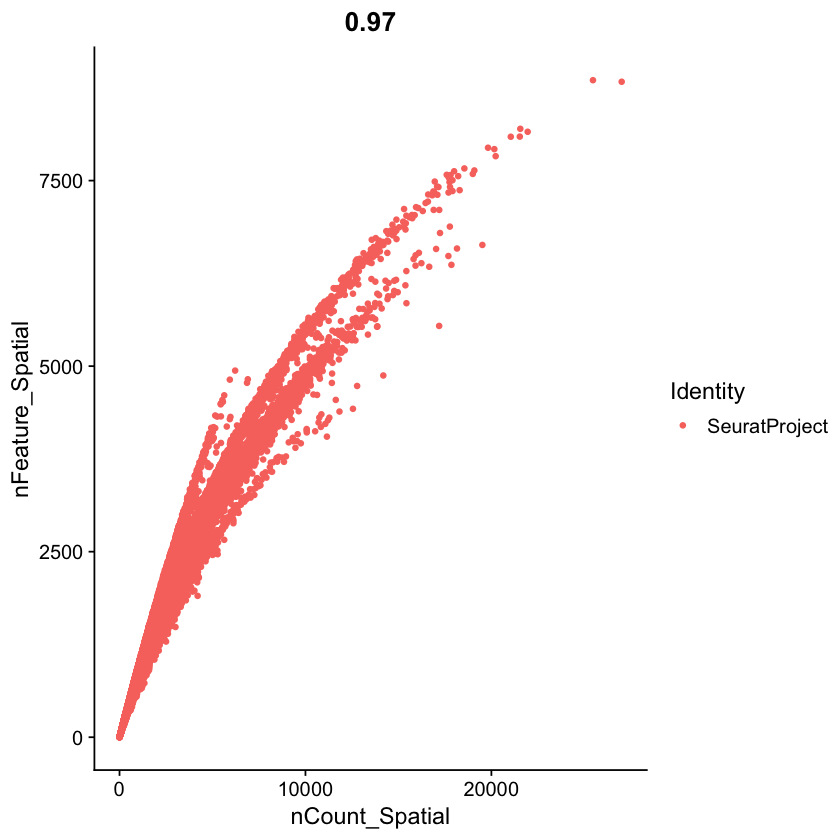

In [3]:
# Quality Control 
print("Running QC...")

FeatureScatter(seurat_obj, feature1 = "nCount_Spatial", feature2 = "nFeature_Spatial")

[1] "Normalizing and Scaling..."


Normalizing layer: counts

Finding variable features for layer counts



[1] "Running PCA..."


PC_ 1 
Positive:  SPP1, VIM, C3, CD44, CHI3L1, CD74, IGFBP7, CD163, LAPTM5, B2M 
	   ANXA1, ZFP36L1, ANXA5, C1QC, FCGBP, SERPINA3, C1QB, C1QA, ANXA2, TNC 
	   CEBPD, FTL, ZFP36L2, CXCR4, PLTP, LGALS1, STAB1, AEBP1, MDM2, S100A10 
Negative:  SNAP25, VSNL1, NRGN, ENC1, OLFM1, SYT1, ATP1A3, SYN1, SNCB, DNM1 
	   STXBP1, SYP, NAPB, CPLX2, CAMK2A, CHN1, CREG2, EEF1A2, SYN2, BEX1 
	   GNG3, HPCA, GRIN1, TMEM130, TUBB2A, NCDN, TMEM59L, RTN1, NDRG4, KIF5A 
PC_ 2 
Positive:  MBP, MOBP, PLP1, PTGDS, APOD, CNP, ERMN, TF, CARNS1, S100B 
	   TMEM144, CRYAB, PLEKHB1, MOG, CERCAM, CLDN11, MAL, DBNDD2, ENPP2, PLEKHH1 
	   ABCA2, CLDND1, GSN, SLAIN1, NKX6-2, MYRF, MTURN, SELENOP, OLIG1, UGT8 
Negative:  MDM2, SLC35E3, MDM1, DYRK2, CAND1, MBOAT1, E2F3, FN1, SYNE2, HIST1H1B 
	   NFIB, CD24, VEGFA, TOP2A, KLHDC8A, HILPDA, EZH2, FLNA, AEBP1, COL6A1 
	   IGFBP2, MCM7, SERPINE1, CALD1, PAGR1, RFX4, AKAP12, TNC, LTF, CDKN2C 
PC_ 3 
Positive:  AQP4, CD74, PMP2, ABCA2, C1QB, ATP1B2, C1QA, ITGB8, C1QC, SELENOP 


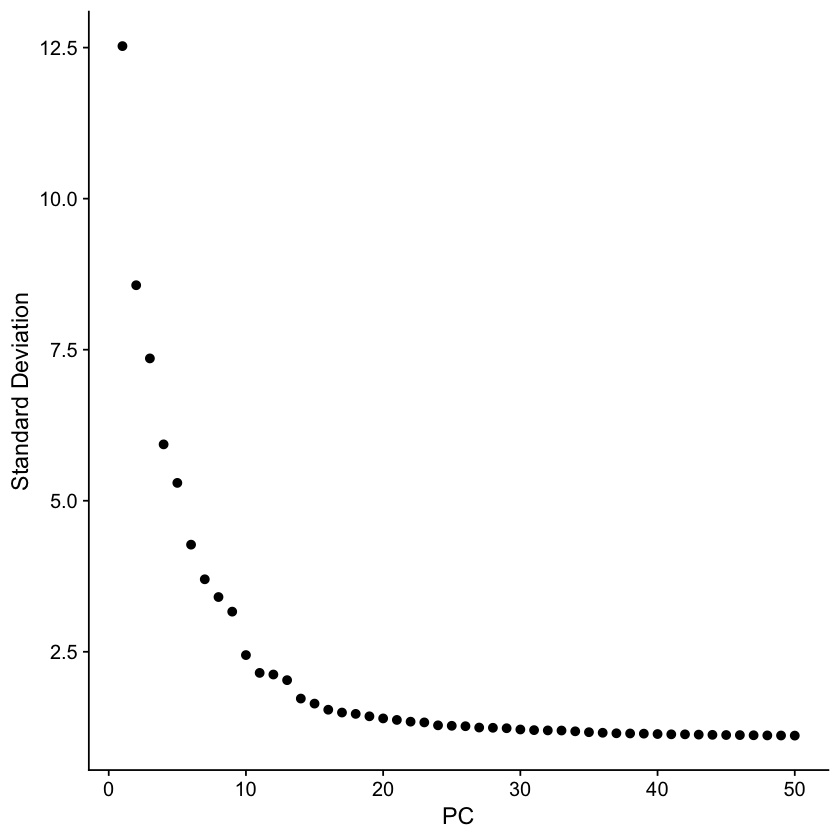

In [4]:
# Normalization & Feature Selection
print("Normalizing and Scaling...")

seurat_obj <- NormalizeData(seurat_obj, normalization.method = "LogNormalize", scale.factor = 10000)
seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 2000)
seurat_obj <- ScaleData(seurat_obj)

# PCA
print("Running PCA...")

seurat_obj <- RunPCA(seurat_obj, features = VariableFeatures(object = seurat_obj))

# Elbow Plot
print(ElbowPlot(seurat_obj, ndims = 50))

In [5]:
# UMAP
dims_use <- 1:23

print("Running UMAP...")
seurat_obj <- RunUMAP(seurat_obj, reduction.key = "UMAP_", dims = dims_use)

[1] "Running UMAP..."


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
12:50:29 UMAP embedding parameters a = 0.9922 b = 1.112

12:50:29 Read 45530 rows and found 23 numeric columns

12:50:29 Using Annoy for neighbor search, n_neighbors = 30

12:50:29 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:50:32 Writing NN index file to temp file /var/folders/lk/54m90rgj1fqg895lxsgx1l180000gn/T//Rtmplkz5e0/file10fe1f1aedda

12:50:32 Searching Annoy index using 10 threads, search_k = 3000

12:50:33 Annoy recall = 100%

12:50:33 Commencing smooth kNN distance calib

In [6]:
# seurat_obj <- readRDS("seurat_codeconv.rds")

[1] "Clustering..."


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 45530
Number of edges: 1674490

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9438
Number of communities: 15
Elapsed time: 8 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (c9cfa64092d539a7052e9ca6c6ca8945-11); on c9cfa64092d539a7052e9ca6c6ca8945@MacBook-Pro-Roman.local<69601>]”


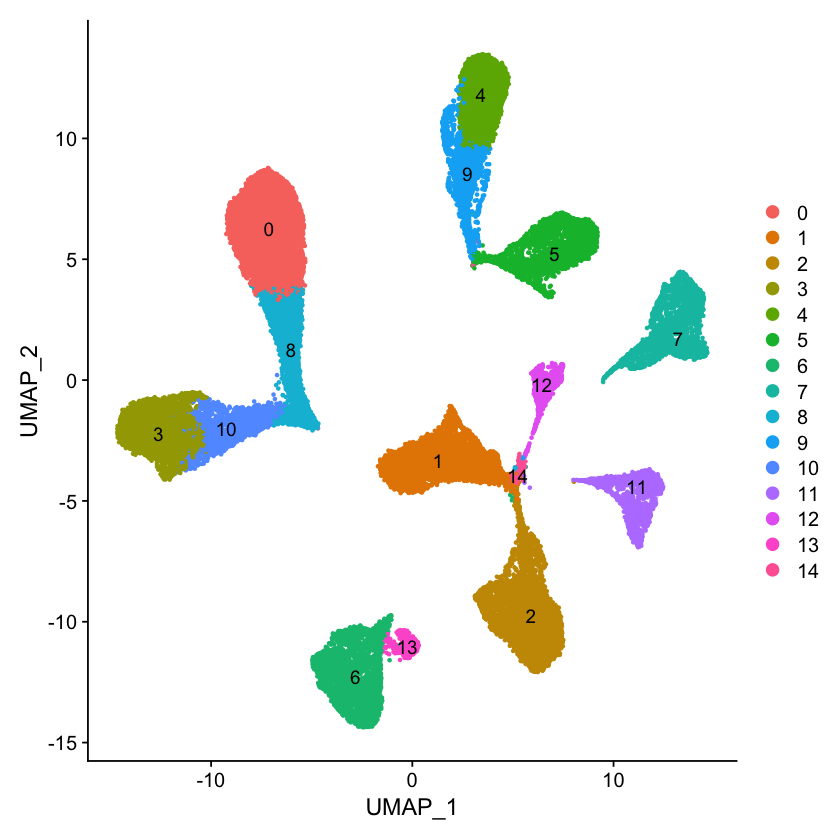

In [7]:
# In Silico Cell Clustering

print("Clustering...")
seurat_obj <- FindNeighbors(seurat_obj, dims = dims_use)
seurat_obj <- FindClusters(seurat_obj, resolution = 0.5) 
DimPlot(seurat_obj, reduction = "umap", label = TRUE, pt.size = 0.5)

In [8]:
all_markers <- FindAllMarkers(
  seurat_obj, 
  only.pos = TRUE,     
  min.pct = 0.25,        
  logfc.threshold = 0.5 
)

library(dplyr)
all_markers_sorted <- all_markers %>%
  group_by(cluster) %>%
  arrange(cluster, desc(avg_log2FC))

write.csv(all_markers_sorted, file = "all_cluster_markers.csv", row.names = FALSE)

print("Markers saved to 'all_cluster_markers.csv'")

top_markers <- all_markers_sorted %>%
    group_by(cluster) %>%
    slice_head(n = 3)

print(top_markers)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14



[1] "Markers saved to 'all_cluster_markers.csv'"
# A tibble: 45 × 7
# Groups:   cluster [15]
   p_val avg_log2FC pct.1 pct.2 p_val_adj cluster gene    
   <dbl>      <dbl> <dbl> <dbl>     <dbl> <fct>   <chr>   
 1     0       3.16 0.799 0.083         0 0       SNCG    
 2     0       3.03 0.793 0.094         0 0       NEFM    
 3     0       2.86 0.392 0.038         0 0       NEFH    
 4     0       5.36 0.333 0.015         0 1       FAM90A26
 5     0       5.29 0.464 0.027         0 1       USP17L3 
 6     0       5.11 0.331 0.021         0 1       USP17L1 
 7     0       4.62 0.464 0.023         0 2       CRABP1  
 8     0       3.95 0.53  0.036         0 2       TOP2A   
 9     0       3.94 0.681 0.059         0 2       HIST1H1B
10     0       3.89 0.711 0.031         0 3       NECAB2  
# ℹ 35 more rows


In [9]:
new_cluster_ids <- c(
  # NEURONAL COMPARTMENT
  "0"  = "Excitatory cortical neurons",
  "3"  = "GABAergic interneurons",
  "8"  = "Neurons",
  "10" = "Interneurons",

  # OLIGODENDROCYTE COMPARTMENT
  "4"  = "Mature myelinating oligodendrocytes",
  "5"  = "OPALIN+ mature oligodendrocytes",
  "9"  = "Reactive oligodendrocytes",

  # GLIOBLASTOMA MALIGNANT STATES
  "2"  = "NPC-like",
  "13" = "OPC-like",
  "6"  = "MES-like",

  # MYELOID COMPARTMENT
  "7"  = "Tumor-associated microglia",

  # VASCULAR / STROMAL COMPARTMENT
  "11" = "Perivascular stromal cells",
  "12" = "Endothelial cells",

  # Necrosis Region
  "14" = "Dying cells",  
  "1"  = "Dying cells"
)

# Apply to Seurat object
seurat_obj <- RenameIdents(seurat_obj, new_cluster_ids)
seurat_obj$CellType <- Idents(seurat_obj)

# seurat_obj <- subset(seurat_obj, idents = "", invert = TRUE)
# seurat_obj$CellType <- droplevels(seurat_obj$CellType)

In [10]:
# seurat_obj <- readRDS("seurat_codeconv.rds")

### Plots 

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


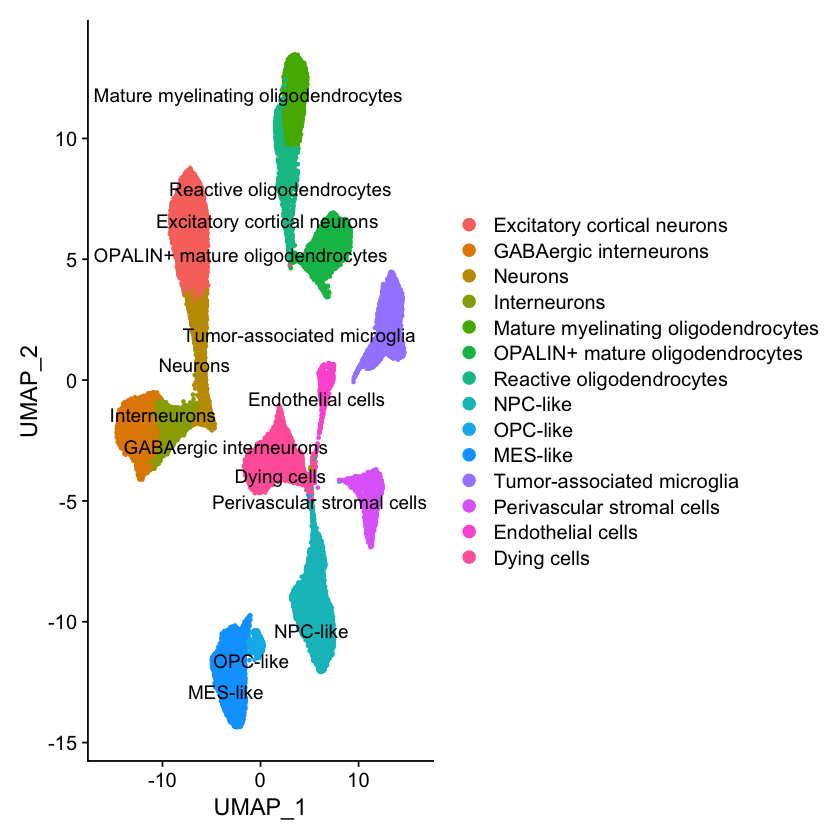

In [11]:
# UMAP Clusters 
DimPlot(seurat_obj, reduction = "umap", repel = TRUE, label = TRUE, pt.size = 0.5) + xlim(-16, 16)

ggsave("CoDeconvClusters.jpeg", plot = last_plot(),
       width = 12.35, height = 10,     
       dpi = 600,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


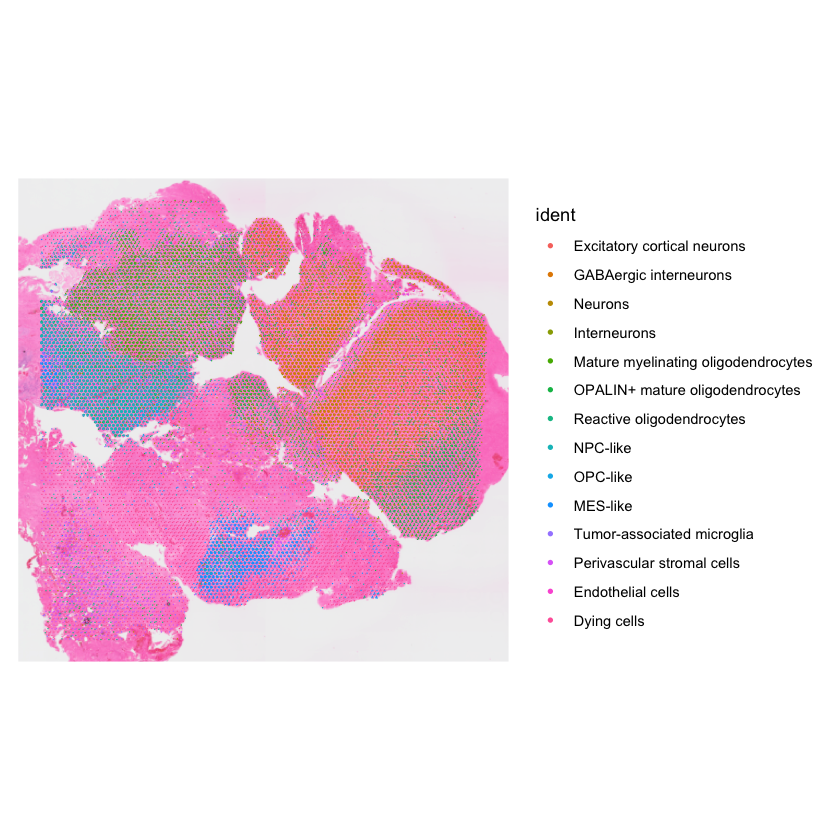

In [12]:
# Spatial Map of the Clusters
SpatialDimPlot(seurat_obj, label = FALSE, label.size = 3, pt.size.factor = 1) + 
    guides(fill = guide_legend(override.aes = list(alpha = 1, stroke = 0)))

ggsave("CoDeconvSpatialClusters.jpeg", plot = last_plot(),
       width = 22, height = 20,     
       dpi = 600,                
       type = "cairo")

This message is displayed once every 8 hours.
Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


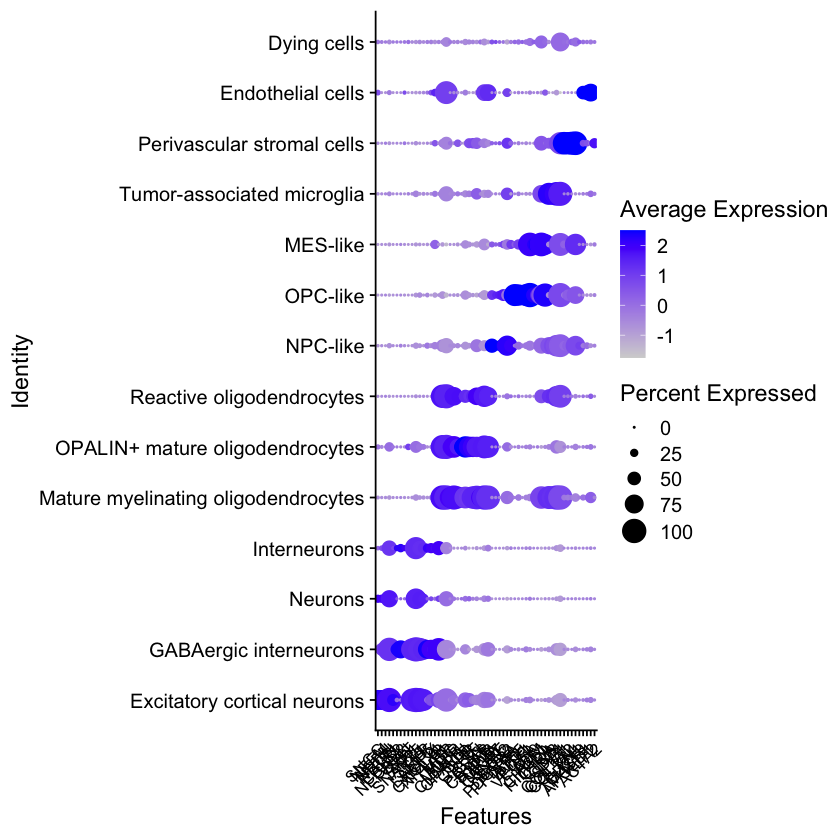

In [13]:
# Define the Glioblastoma (GBM) marker genes organized by compartment & cluster

genes_to_plot <- c(
  # NEURONAL COMPARTMENT
  "SNCG", "NEFM", "NEFH", "NRGN", "TBR1",       # 0: Excitatory cortical neurons
  "CALB2", "NECAB2", "PDYN", "SST",             # 3: GABAergic interneurons
  "SYN1", "SNAP25", "SYT1", "SYP",              # 8: Neurons (Synaptic / Neuropil)
  "LAMP5", "HOPX", "CXCL14", "NPTXR",           # 10: Interneurons

  # OLIGODENDROCYTE / GLIAL COMPARTMENT
  "PLP1", "MBP", "MOG", "MOBP", "CLDN11",       # 4: Mature myelinating oligodendrocytes
  "OPALIN", "SCD", "QDPR", "TF",                # 5: OPALIN+ mature oligodendrocytes
  "GSN", "PCSK6", "CRYAB", "S100B",             # 9: Reactive oligodendrocytes

  # GLIOBLASTOMA MALIGNANT STATES
  "TOP2A", "MKI67", "CENPF", "EZH2", "SOX2",    # 2: NPC-like malignant cells
  "PDGFRA", "PPDPFL", "ATF5", "LMO1", "PDK1",   # 13: OPC-like malignant cells
  "VEGFA", "CA9", "ADM", "CHI3L1", "HILPDA",    # 6: MES-like malignant cells

  # MYELOID COMPARTMENT
  "C1QA", "C1QB", "CD74", "SPP1",               # 7: Tumor-associated microglia

  # VASCULAR / STROMAL COMPARTMENT
  "COL1A1", "COL1A2", "COL3A1", "FN1", "CD248",  # 11: Perivascular stromal cells
  "TM4SF1", "APOLD1", "KLF2", "ACTA2"            # 12: Endothelial cells
)

genes_to_plot <- unique(genes_to_plot)

# Remove any genes not found in the Seurat object
genes_to_plot <- genes_to_plot[genes_to_plot %in% rownames(seurat_obj)]

# Generate the DotPlot
DotPlot(
  seurat_obj,
  features = genes_to_plot
) + 
  RotatedAxis() +                   
  theme(axis.text.x = element_text(size = 10))

# Save the plot
ggsave("CoDeconvDotPlot.jpeg", plot = last_plot(),
       width = 22, height = 5.5,     
       dpi = 600,                 
       type = "cairo")

In [14]:
saveRDS(seurat_obj, "seurat_codeconv.rds")

### Calculate co-localization matrix

Computing nearest neighbor graph

Computing SNN



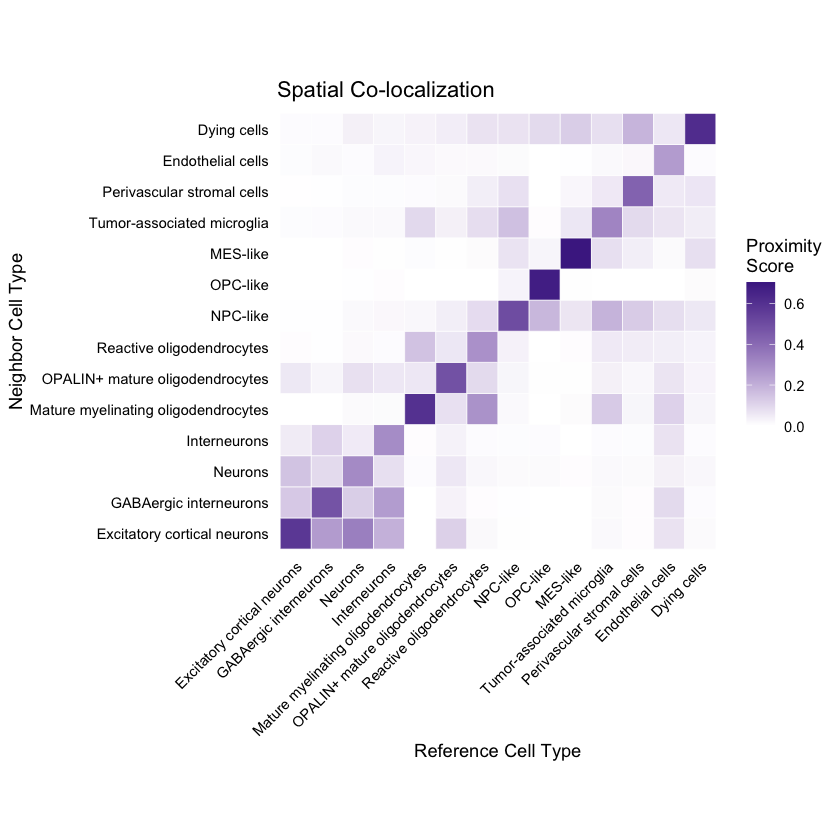

In [15]:
library(reshape2)

coords <- GetTissueCoordinates(seurat_obj)
neighbor_graph <- FindNeighbors(as.matrix(coords[, 1:2]), k.param = 6)$nn

Idents(seurat_obj) <- "CellType"
cell_types <- levels(seurat_obj)
type_matrix <- model.matrix(~ 0 + CellType, data = seurat_obj@meta.data)
colnames(type_matrix) <- cell_types

co_occurrence <- t(type_matrix) %*% neighbor_graph %*% type_matrix

co_occ_norm <- as.matrix(co_occurrence)
co_occ_norm <- sweep(co_occ_norm, 1, rowSums(co_occ_norm), FUN = "/")

p <- ggplot(melt(co_occ_norm), aes(Var1, Var2, fill = value)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "white", high = "#4b2991", name = "Proximity\nScore") +
  coord_fixed() + 
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(color = "black"),
    panel.grid = element_blank()
  ) +
  labs(title = "Spatial Co-localization", x = "Reference Cell Type", y = "Neighbor Cell Type")

ggsave("spatial_colocalization_heatmap.png", plot = p, dpi = 500, width = 8, height = 8)

# Display plot
print(p)

# CellChat

Spatially-resolved ligand-receptor communication on the CoDeconv coordinates
(mouse database). Communication is restricted to a **100 um interaction
distance** (`interaction.range = 100`), with the 10x Visium spot pitch
(`contact.range = 100`) used for contact-dependent signaling. Outgoing and
incoming signaling roles are summarised as heatmaps.

In [3]:
seurat_obj <- readRDS('seurat_codeconv.rds')

In [6]:
# CellChat spatial cell-cell communication
library(CellChat)
library(ComplexHeatmap)

# Cluster communication by the fine-grained (CD45 +/-) annotation
Idents(seurat_obj) <- "CellType"

# 1) Normalised expression (genes x cells). Realise the BPCells stream into a
#    sparse matrix, which is the input format createCellChat() expects.
data.input <- Seurat::GetAssayData(seurat_obj, assay = "Spatial", layer = "data")
data.input <- as(data.input, "dgCMatrix")

# 2) Cell-level metadata: the grouping labels CellChat aggregates over
meta <- data.frame(labels = Idents(seurat_obj), row.names = colnames(seurat_obj))
meta$labels <- droplevels(meta$labels)

# 3) Spatial coordinates (full-resolution pixel space: imagerow, imagecol)
coords <- GetTissueCoordinates(seurat_obj)
spatial.locs <- as.matrix(coords[, 1:2])
rownames(spatial.locs) <- colnames(seurat_obj)

print(dim(data.input))
print(table(meta$labels))
print(head(spatial.locs))

[1] 18031 45530

        Excitatory cortical neurons              GABAergic interneurons 
                               6580                                4294 
                            Neurons                        Interneurons 
                               2924                                1908 
Mature myelinating oligodendrocytes     OPALIN+ mature oligodendrocytes 
                               4128                                3388 
          Reactive oligodendrocytes                            NPC-like 
                               2220                                5153 
                           OPC-like                            MES-like 
                                476                                3308 
         Tumor-associated microglia          Perivascular stromal cells 
                               3099                                1797 
                  Endothelial cells                         Dying cells 
                                78

In [7]:
# Pixel -> micron conversion from the Visium scale factors
scale.factors <- jsonlite::fromJSON(
  txt = file.path(data_dir, "spatial", "scalefactors_json.json"))
spot.size <- 55  # 10x Visium spot size (µm)
conversion.factor <- spot.size / scale.factors$spot_diameter_fullres
spatial.factors <- data.frame(ratio = conversion.factor, tol = spot.size / 2)

cat(sprintf("pixel->um ratio = %.5f  | tol = %.1f um\n",
            spatial.factors$ratio, spatial.factors$tol))

cellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels",
                           datatype = "spatial", coordinates = spatial.locs,
                           spatial.factors = spatial.factors)

# ligand-receptor database 
cellchat@DB <- CellChatDB.human
# cellchat@DB <- CellChatDB.mouse

pixel->um ratio = 0.25095  | tol = 27.5 um
[1] "Create a CellChat object from a data matrix"
Create a CellChat object from spatial transcriptomics data... 


Warning message in createCellChat(object = data.input, meta = meta, group.by = "labels", :
“The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Excitatory cortical neurons, GABAergic interneurons, Neurons, Interneurons, Mature myelinating oligodendrocytes, OPALIN+ mature oligodendrocytes, Reactive oligodendrocytes, NPC-like, OPC-like, MES-like, Tumor-associated microglia, Perivascular stromal cells, Endothelial cells, Dying cells 


In [8]:
gc()

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,7281345,388.9,14306514,764.1,NA,9415871,502.9
Vcells,134455110,1025.9,393409987,3001.5,16384,428246045,3267.3


In [9]:
# Preprocessing: restrict to signaling genes, then flag over-expressed L-R pairs
cellchat <- subsetData(cellchat)
plan("multicore", workers = 6)
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)

# Communication probabilities with a 100 um spatial interaction distance.
#   interaction.range = 100  -> ligands act over <= 100 um 
#   contact.range     = 100  -> center-to-center spot pitch for 10x Visium
#   scale.distance    = 0.04 -> maps the (um) distances into CellChat's kernel
# NOTE: distance.use = TRUE  is compute/memory heavy;

cellchat <- computeCommunProb(cellchat,
                              type = "truncatedMean", trim = 0.1,
                              distance.use = TRUE,
                              interaction.range = 100,
                              scale.distance = 0.04,   # calibrated so min scaled distance ~1.5 (CellChat requires [1,2])
                              contact.dependent = TRUE,
                              contact.range = 100)

# Keep interactions supported by enough cells, then aggregate the network
cellchat <- filterCommunication(cellchat, min.cells = 10)
cellchat <- computeCommunProbPathway(cellchat)
cellchat <- aggregateNet(cellchat)

The number of highly variable ligand-receptor pairs used for signaling inference is 3071 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on spatial transcriptomics data using distances as constraints of the computed communication probability <<< [2026-08-09 13:39:42.515887]"
The input L-R pairs have both secreted signaling and contact-dependent signaling. Run CellChat in a contact-dependent manner for `Cell-Cell Contact` signaling, and in a diffusion manner based on the `interaction.range` for other L-R pairs. 
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-08-09 15:50:01.182633]"


In [ ]:
cellchat <- readRDS('cellchat_codeconv.rds')

agg_record_436662840 
                   2

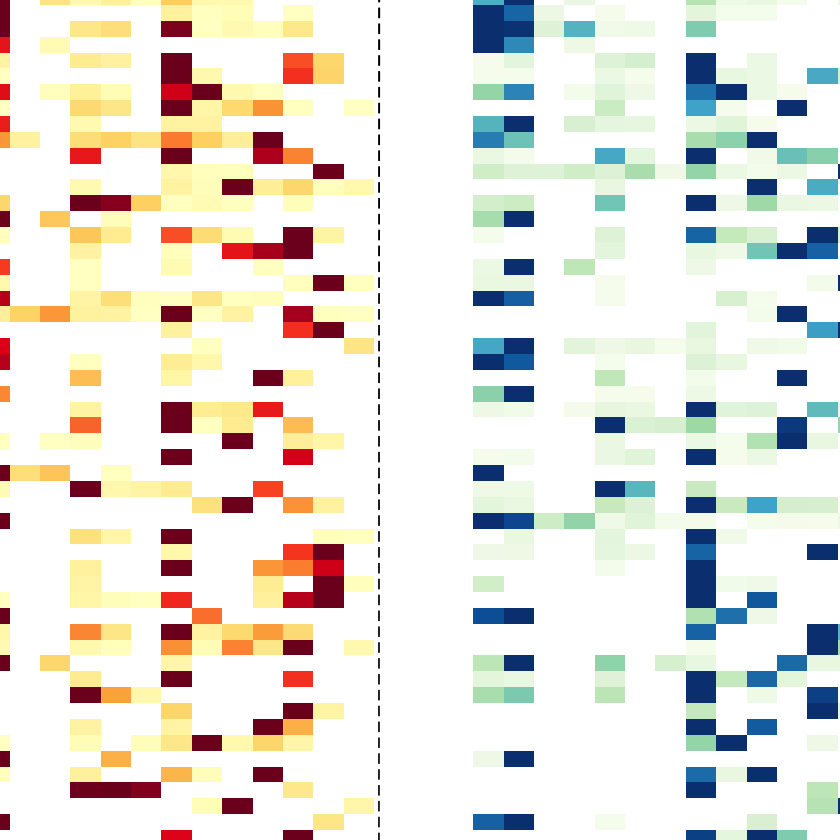

In [22]:
# Per-pathway network centrality (needed for the signaling-role heatmaps)
options(future.rng.onMisuse = "ignore")   # silence benign parallel-RNG warnings from future.apply
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

# Outgoing vs incoming signaling-role heatmaps (pathways x cell types)
ht_out <- netAnalysis_signalingRole_heatmap(cellchat, pattern = "outgoing",
            width = 9, height = 45, color.heatmap = "YlOrRd")
ht_in  <- netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming",
            width = 9, height = 45, color.heatmap = "GnBu")

# netAnalysis_signalingRole_heatmap names BOTH heatmaps "Relative strength", so
# `ht_out + ht_in` collide on draw() ("Viewport 'Relative strength_..._body_1_1'
# was not found"). Give each a unique heatmap name and legend title first.
ht_out@name <- "Outgoing"; ht_out@matrix_color_mapping@name <- "Outgoing"
ht_in@name  <- "Incoming"; ht_in@matrix_color_mapping@name  <- "Incoming"

# Display the two heatmaps side by side
draw(ht_out + ht_in, ht_gap = unit(1, "cm"))

# Save a publication-resolution figure
png("CellChat_signalingRole_out_in.png",
    width = 10, height = 22, units = "in", res = 600)
draw(ht_out + ht_in, ht_gap = unit(1, "cm"))
dev.off()

In [ ]:
saveRDS(cellchat, "cellchat_codeconv.rds")
print("CellChat object saved to 'cellchat_codeconv.rds'")